# 01 - EDA and leakage audit

*This notebook is a thin view: it renders artifacts persisted by the pipeline (`make data features train evaluate figures`). No result is computed here.*

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display

RESULTS = Path.cwd().parent / "results" / "metrics"
FIGURES = Path.cwd().parent / "reports" / "figures"

def load(name):
    with open(RESULTS / f"{name}.json") as fh:
        return json.load(fh)

def fig(name):
    display(Image(str(FIGURES / f"{name}.png"), width=880))


## Dataset shape, class balance, identity coverage

In [2]:
eda = load('stage1_eda')
{k: eda[k] for k in ['n_rows','n_cols','fraud_rate','n_fraud','identity_coverage','span_days']}

{'n_rows': 590540,
 'n_cols': 438,
 'fraud_rate': 0.03499000914417313,
 'n_fraud': 20663,
 'identity_coverage': 0.2442391709283029,
 'span_days': 182}

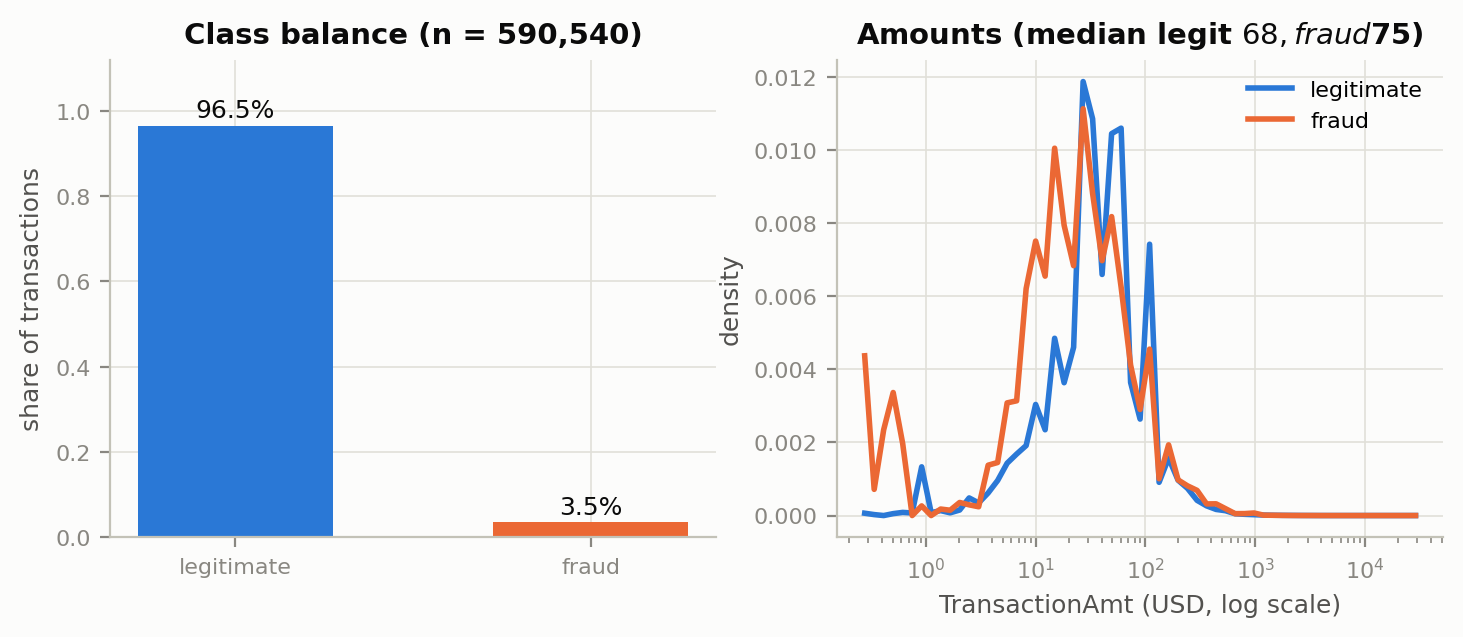

In [3]:
fig('figure_01_class_balance_amounts')

## Temporal structure

Volume and fraud rate move week to week; the last two months are visibly different from the first four. Any evaluation that shuffles these rows together is answering a question production never asks.

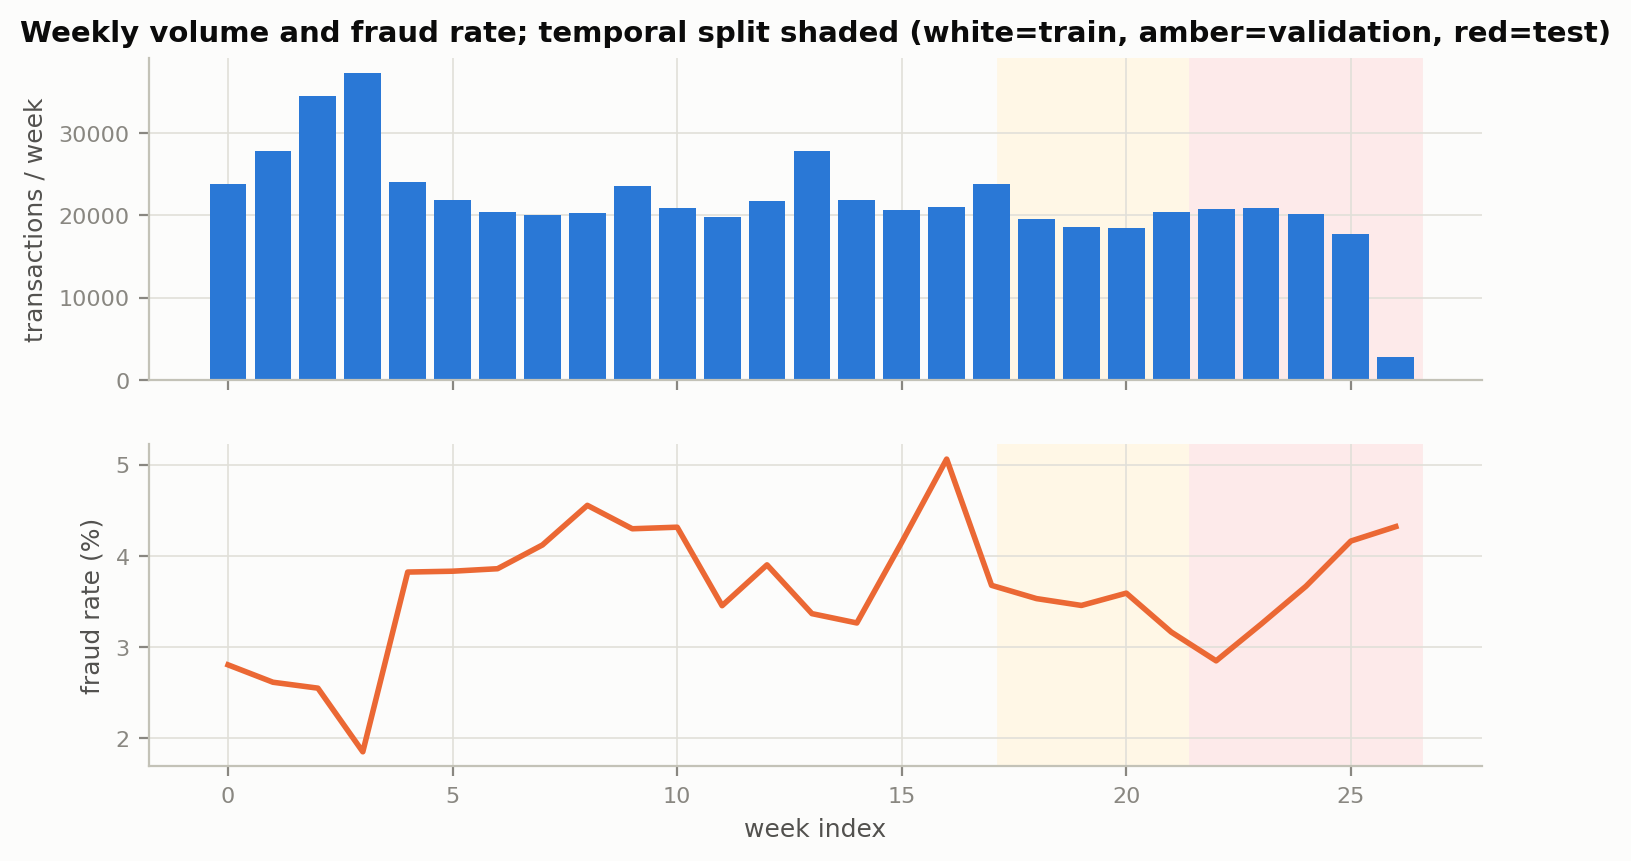

In [4]:
fig('figure_02_volume_fraud_over_time')

In [5]:
pd.DataFrame(eda['monthly'])

,month,n,fraud_rate
0,0,130968,0.024762
1,1,89838,0.040373
2,2,91768,0.040319
3,3,98027,0.039265
4,4,85303,0.034723
5,5,94636,0.034680


## Missingness by feature block

In [6]:
pd.Series(eda['missingness_by_block']).sort_values().map('{:.1%}'.format)

B_counts         0.0%
A_core          19.4%
E_vesta         43.0%
D_matches       49.9%
C_timedeltas    58.2%
F_identity      84.5%
dtype: str

## Leakage audit (why random CV is invalid here)

1. **Temporal structure.** Transactions are a time series of adversarial
   behavior; random K-fold trains on the future and validates on the past.
2. **D-features.** `D1`-`D15` are time deltas anchored to calendar events;
   shuffled folds let the model interpolate between past and future values of
   the same underlying clock.
3. **Entity aggregations.** Frequency/velocity features accumulate per card
   profile. Computed naively (full-table counts) they encode the future;
   computed causally they still correlate strongly across a card's
   transactions, so shuffled folds place the same entity on both sides of the
   split. The 1st-place IEEE-CIS solution (Deotte & Yakovlev) made exactly
   this point: their UID-level features required GroupKFold-by-month to
   validate honestly -- client-level memorization otherwise masquerades as
   generalization.
4. **Labels.** `isFraud` propagates to downstream transactions of a flagged
   account, so a shuffled split can leak one fraud episode across folds.

Consequences for this project: chronological splits everywhere, GroupKFold
by month for model selection, expanding-window (strictly past) aggregations
enforced by `tests/test_causal_features.py`, and no label-based aggregation
features at all (chargeback labels arrive weeks late in production).